# AMES Revision Notebook
**M.Tech Data Science & AI — Semester I**

A complete revision pack: **theory + explanation + runnable Python example** for every topic in the syllabus. Each example imports its libraries, builds sample data, runs the test/calculation, and explains the output.

> **How to use:** Read the theory block, then run the code cell below it. The output is the answer you would write in the exam (just round nicely).

---

## Table of Contents

**Part A — Probability & Distributions**
1. [Bayes Theorem](#1.-Bayes-Theorem) *(theory only)*
2. [Normal Distribution](#2.-Normal-Distribution)
3. [Confidence Interval](#3.-Confidence-Interval-(CI))

**Part B — Hypothesis Testing**
4. [Z-test](#4.-Z-test)
5. [Type I & Type II Errors](#5.-Type-I-&-Type-II-Errors)
6. [One-sample t-test](#6.-One-sample-t-test)
7. [Two-sample (independent) t-test](#7.-Two-sample-(independent)-t-test)
8. [Paired t-test](#8.-Paired-t-test)
9. [Chi-square Tests](#9.-Chi-square-Tests) — (a) Independence  &  (b) Goodness of Fit
10. [One-way ANOVA](#10.-One-way-ANOVA)

**Part C — Linear Algebra**
11. [Linear dependence & independence](#11.-Linear-Dependence-&-Independence)
12. [Eigenvalues & Eigenvectors](#12.-Eigenvalues-&-Eigenvectors)
13. [PCA from scratch](#13.-PCA-from-Scratch)

**Part D — Calculus & Optimization**
14. [Derivatives](#14.-Derivatives)
15. [Optimization — single variable](#15.-Optimization-\—-Single-Variable)
16. [Optimization — two variables](#16.-Optimization-\—-Two-Variables)
17. [Jacobian matrix](#17.-Jacobian-Matrix)
18. [Hessian matrix](#18.-Hessian-Matrix)


## Setup — common imports (run once)

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import sympy as sp
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
print('Setup OK')

Setup OK


---
# Part A — Probability & Distributions

## 1. Bayes Theorem
*(theory only — no code, as requested)*

**Formula**
$$P(A \mid B) \;=\; \frac{P(B \mid A)\,P(A)}{P(B)}, \qquad P(B) = \sum_i P(B \mid A_i)\,P(A_i)$$

**Words:** Bayes' theorem updates the probability of a hypothesis $A$ given new evidence $B$. It flips a known conditional probability $P(B|A)$ into the desired direction $P(A|B)$.

**Terminology**
- $P(A)$ — *prior* (belief before seeing evidence)
- $P(B \mid A)$ — *likelihood* (how probable the evidence is if A is true)
- $P(B)$ — *marginal / evidence* (overall probability of the evidence)
- $P(A \mid B)$ — *posterior* (updated belief)

**Classic exam example — disease testing**

A disease affects 1% of a population. A test is 99% sensitive (true positive) and 95% specific (true negative). If a person tests positive, what is $P(\text{Disease} \mid +)$?

$$P(D \mid +) = \frac{P(+ \mid D)\,P(D)}{P(+ \mid D)\,P(D) + P(+ \mid \bar D)\,P(\bar D)} = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.05 \times 0.99} = \frac{0.0099}{0.0594} \approx 0.1667$$

**Key insight:** Even with a 99% accurate test, only ~17% of positives are truly diseased — because the disease itself is rare (low prior). This is why doctors confirm with a second test.

**Where it appears in DS/AI:** Naive Bayes classifier, Bayesian inference, A/B testing, spam filters.


## 2. Normal Distribution

**Definition.** A continuous distribution symmetric about its mean $\mu$, with spread controlled by standard deviation $\sigma$:
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Key properties (memorize for exam):**
- Mean = Median = Mode = $\mu$
- Symmetric, bell-shaped
- **68-95-99.7 rule**: ~68% of values lie within $\mu\pm\sigma$, ~95% within $\mu\pm 2\sigma$, ~99.7% within $\mu\pm 3\sigma$
- **Standard normal** $Z \sim N(0, 1)$: obtained by $Z = (X - \mu)/\sigma$
- The Central Limit Theorem (CLT) says sample means are approximately normal for large $n$ — this is why the normal shows up everywhere

**When you'll use it:** to compute probabilities, percentiles, critical values for Z/t-tests.


In [2]:
# Example: A factory produces bolts with mean length mu=50 mm, sigma=2 mm.
# Q1: What % of bolts are between 48 and 52 mm?
# Q2: What's the 95th percentile bolt length?

mu, sigma = 50, 2

# P(48 <= X <= 52)
p = stats.norm.cdf(52, mu, sigma) - stats.norm.cdf(48, mu, sigma)
print(f'P(48 <= X <= 52) = {p:.4f}  (~68% as expected from 1-sigma rule)')

# 95th percentile
p95 = stats.norm.ppf(0.95, mu, sigma)
print(f'95th percentile length = {p95:.3f} mm')

# Sample 1000 values to visualize
sample = stats.norm.rvs(mu, sigma, size=1000, random_state=42)
print(f'Sample mean = {sample.mean():.3f},  Sample std = {sample.std(ddof=1):.3f}')

P(48 <= X <= 52) = 0.6827  (~68% as expected from 1-sigma rule)
95th percentile length = 53.290 mm
Sample mean = 50.039,  Sample std = 1.958


## 3. Confidence Interval (CI)

**Definition.** A range that has a specified probability (e.g. 95%) of containing the **true population parameter** if we repeated the sampling many times.

**Formula for a population mean (σ unknown — use t):**
$$\bar x \;\pm\; t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}$$
where $\bar x$ = sample mean, $s$ = sample SD, $n$ = sample size, $t_{\alpha/2,n-1}$ = critical t-value.

**Steps**
1. Compute $\bar x$ and $s$ from data.
2. Compute standard error $SE = s/\sqrt{n}$.
3. Look up $t_{\alpha/2}$ for confidence level $(1-\alpha)$ at $n-1$ degrees of freedom.
4. CI = $(\bar x - t \cdot SE,\; \bar x + t \cdot SE)$.

**Interpretation:** "We are 95% confident the true mean lies in this interval." It does **not** mean a single interval has 95% probability of containing $\mu$ — $\mu$ is fixed; the interval is random.


In [ ]:
# Example: heights (cm) of 12 students. Build a 95% CI for mean height.
heights = np.array([168, 172, 165, 178, 170, 174, 169, 171, 167, 173, 175, 170])

n = len(heights)
xbar = heights.mean()
s = heights.std(ddof=1) 
se = s / np.sqrt(n)

ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f'n={n},  mean={xbar:.3f},  s={s:.3f},  SE={se:.3f}')
print(f'95% CI for mean height = ({ci_low:.3f}, {ci_high:.3f})')
print(f'Interpretation: with 95% confidence, true mean height lies between {ci_low:.2f} and {ci_high:.2f} cm.')

n=12,  mean=171.000,  s=3.643,  SE=1.052
95% CI for mean height = (168.685, 173.315)
Interpretation: with 95% confidence, true mean height lies between 168.69 and 173.31 cm.


---
# Part B — Hypothesis Testing

## General hypothesis-testing recipe (use for every test below)

1. **State** $H_0$ (null) and $H_1$ (alternative).
2. **Choose** significance level $\alpha$ (usually 0.05).
3. **Compute** the test statistic from data.
4. **Find** the p-value (or compare statistic to critical value).
5. **Decide:** if p-value < α → **Reject** $H_0$; else → **Fail to reject** $H_0$.
6. **Conclude** in plain English (about the population).


## 4. Z-test

**Use when:** comparing a sample mean to a known population mean **and the population standard deviation σ is known** (or the sample is very large so $s \approx \sigma$).

**Test statistic:**
$$Z = \frac{\bar x - \mu_0}{\sigma / \sqrt{n}}$$

**Decision:** for two-sided test at α=0.05, reject $H_0$ if $|Z| > 1.96$.

**Difference from t-test:** the Z-test uses the *known* σ and the standard normal distribution; the t-test uses the *sample* SD $s$ and the t-distribution.


In [ ]:
# Example: A factory claims battery life has mean 500 hrs with sigma=20.
# Sample of 36 batteries gives mean 495 hrs. Test at alpha=0.05.

mu0, sigma, n, xbar = 500, 20, 36, 495
alpha = 0.05

z = (xbar - mu0) / (sigma / np.sqrt(n))
p = 2 * (1 - stats.norm.cdf(abs(z)))   # two-sided

print(f'Z = {z:.4f},  p-value = {p:.4f}')
# z_crit = stats.norm.ppf(1 - alpha/2)
# print(f'Critical Z (two-sided, alpha=0.05) = +/-{z_crit:.3f}')
print('Decision:', 'Reject H0' if p < alpha else 'Fail to reject H0')

Z = -1.5000,  p-value = 0.1336
Critical Z (two-sided, alpha=0.05) = +/-1.960
Decision: Fail to reject H0


## 5. Type I & Type II Errors

|  | $H_0$ True | $H_0$ False |
|---|---|---|
| **Reject $H_0$** | **Type I error** (probability = α) | Correct decision (Power = 1−β) |
| **Fail to reject $H_0$** | Correct decision (1−α) | **Type II error** (probability = β) |

- **Type I (α):** false alarm — concluding an effect exists when it doesn't.
- **Type II (β):** missed detection — failing to detect a real effect.
- **Power = 1 − β:** probability of correctly detecting a true effect. Increased by larger $n$, larger effect size, larger α.

**Trade-off:** Lowering α (e.g. 0.01) makes Type I rarer but Type II more likely (β rises). The only way to reduce both simultaneously is to collect more data.


In [5]:
# Simulation: estimate alpha and beta for a one-sample Z-test.
# H0: mu = 100 vs H1: mu != 100.  True mu = 102, sigma = 10, n = 30, alpha = 0.05.

rng = np.random.default_rng(0)
mu0, sigma, n, alpha = 100, 10, 30, 0.05
true_mu_null  = 100   # H0 actually true
true_mu_alt   = 102   # H0 actually false (effect present)
z_crit = stats.norm.ppf(1 - alpha/2)

reps = 20000

# Type I: H0 true, how often do we wrongly reject?
samples = rng.normal(true_mu_null, sigma, size=(reps, n))
z_stats = (samples.mean(axis=1) - mu0) / (sigma/np.sqrt(n))
type1_rate = np.mean(np.abs(z_stats) > z_crit)

# Type II: H0 false, how often do we fail to reject?
samples = rng.normal(true_mu_alt, sigma, size=(reps, n))
z_stats = (samples.mean(axis=1) - mu0) / (sigma/np.sqrt(n))
type2_rate = np.mean(np.abs(z_stats) <= z_crit)
power = 1 - type2_rate

print(f'Estimated Type I error (alpha) = {type1_rate:.4f}  (expect ~0.05)')
print(f'Estimated Type II error (beta) = {type2_rate:.4f}')
print(f'Power = 1 - beta              = {power:.4f}')

Estimated Type I error (alpha) = 0.0503  (expect ~0.05)
Estimated Type II error (beta) = 0.8062
Power = 1 - beta              = 0.1938


## 6. One-sample t-test

**Use when:** comparing a sample mean to a hypothesized value, with **σ unknown** (use sample SD $s$).

**Hypotheses:** $H_0: \mu = \mu_0$  vs  $H_1: \mu \ne \mu_0$ (two-sided).

**Test statistic:**
$$t = \frac{\bar x - \mu_0}{s/\sqrt{n}}, \qquad df = n - 1$$

**Assumptions:** data approximately normal (or $n$ large by CLT), random sample.


In [ ]:
# Example: a coffee shop claims average serving = 250 ml. Sample of 15 cups:
servings = np.array([248, 252, 247, 250, 249, 246, 251, 253, 245, 248, 250, 247, 249, 252, 250])
mu0, alpha = 250, 0.05

t_stat, p_val = stats.ttest_1samp(servings, mu0,alternative='two-sided')
# alternative="two-sided", "greater","less"
print(f'n = {len(servings)},  mean = {servings.mean():.3f},  s = {servings.std(ddof=1):.3f}')
print(f't = {t_stat:.4f},  p = {p_val:.4f}')
print('Decision:', 'Reject H0' if p_val < alpha else 'Fail to reject H0 — claim of 250 ml is consistent with data')

n = 15,  mean = 249.133,  s = 2.326
t = -1.4432,  p = 0.1710
Decision: Fail to reject H0 — claim of 250 ml is consistent with data


## 7. Two-sample (independent) t-test

**Use when:** comparing means of **two independent groups** (e.g. drug vs placebo, men vs women).

**Hypotheses:** $H_0: \mu_1 = \mu_2$ vs $H_1: \mu_1 \ne \mu_2$.

**Test statistic (equal variance assumed — pooled):**
$$t = \frac{\bar x_1 - \bar x_2}{s_p\sqrt{\tfrac{1}{n_1}+\tfrac{1}{n_2}}}, \quad s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}, \quad df = n_1+n_2-2$$

**Welch's t-test** (use if variances clearly unequal): same formula but $s_1^2/n_1 + s_2^2/n_2$ in the denominator (no pooling) and a different df formula. Set `equal_var=False` in scipy.


In [ ]:
# Example: test scores for two teaching methods.
method_A = np.array([78, 82, 85, 79, 88, 84, 80, 83, 81, 86])
method_B = np.array([72, 75, 78, 74, 80, 77, 73, 76, 79, 74])

t_stat, p_val = stats.ttest_ind(method_A, method_B, equal_var=True,alternative='two-sided')
# alternative="two-sided", "greater","less"
print(f'Mean A = {method_A.mean():.2f},  Mean B = {method_B.mean():.2f}')
print(f't = {t_stat:.4f},  p = {p_val:.6f}')
print('Decision:', 'Reject H0 — methods differ significantly' if p_val < 0.05 else 'No significant difference')

# 95% CI for the difference (mean_A - mean_B)
n1, n2 = len(method_A), len(method_B)
sp2 = ((n1-1)*method_A.var(ddof=1) + (n2-1)*method_B.var(ddof=1)) / (n1+n2-2)
se = np.sqrt(sp2*(1/n1 + 1/n2))
diff = method_A.mean() - method_B.mean()
ci = stats.t.interval(0.95, df=n1+n2-2, loc=diff, scale=se)
print(f'95% CI for (A - B): ({ci[0]:.3f}, {ci[1]:.3f})')

Mean A = 82.60,  Mean B = 75.80
t = 5.1650,  p = 0.000065
Decision: Reject H0 — methods differ significantly
95% CI for (A - B): (4.034, 9.566)


## 8. Paired t-test

**Use when:** the same subjects are measured **twice** (e.g. before vs after, left vs right hand, weight before/after diet). The samples are *paired/matched*, not independent.

**Idea:** compute differences $d_i = x_i^{(\text{after})} - x_i^{(\text{before})}$, then run a **one-sample t-test on the differences** with $H_0: \mu_d = 0$.

**Test statistic:**
$$t = \frac{\bar d - 0}{s_d / \sqrt{n}}, \qquad df = n - 1$$

**Why "paired" is more powerful:** subject-level variation (which is large) cancels out, so smaller effects become detectable.


In [ ]:
# Example: blood pressure before and after a drug, same 10 patients.
before = np.array([140, 138, 145, 150, 142, 148, 139, 146, 143, 144])
after  = np.array([135, 134, 140, 144, 138, 141, 137, 140, 139, 142])

t_stat, p_val = stats.ttest_rel(before, after,alternative='two-sided')
diff = before - after
print(f'Mean reduction = {diff.mean():.3f} mmHg')
print(f't = {t_stat:.4f},  p = {p_val:.6f}')
print('Decision:', 'Reject H0 — drug significantly reduces BP' if p_val < 0.05 else 'No significant effect')

Mean reduction = 4.500 mmHg
t = 8.6248,  p = 0.000012
Decision: Reject H0 — drug significantly reduces BP


## 9. Chi-square Tests

The chi-square statistic compares **observed** counts to **expected** counts. There are **two** flavours you must know:

| Variant | Question it answers | scipy call |
|---|---|---|
| **9a. Test of Independence** | Are two *categorical variables* related? (uses a contingency table) | `stats.chi2_contingency(table)` |
| **9b. Goodness of Fit (GoF)** | Does my *single* observed distribution match a hypothesized one? | `stats.chisquare(obs, exp)` |

**Common formula (both):**
$$\chi^2 = \sum \frac{(O - E)^2}{E}$$
where $O$ = observed count, $E$ = expected count. **Reject** $H_0$ when $\chi^2$ is large (p < α).

**Assumption (both):** every expected count $E \ge 5$ (otherwise use Fisher's exact test or pool categories).

---

### 9a) Chi-square Test of Independence

**Use when:** testing whether two **categorical** variables are independent. Data is presented in a **contingency table** (rows = categories of variable 1, columns = categories of variable 2).

**Hypotheses:**
- $H_0$: the two variables are **independent**
- $H_1$: the two variables are **associated**

**Expected counts under independence:**
$$E_{ij} = \frac{(\text{row total}_i) \times (\text{column total}_j)}{\text{grand total}}$$

**Degrees of freedom:** $df = (r-1)(c-1)$ where $r$ = #rows, $c$ = #cols.


In [9]:
# Example: Is gender independent of preferred drink?
#                Tea  Coffee  Juice
#   Male          30     25      15
#   Female        20     35      25

obs = np.array([[30, 25, 15],
                [20, 35, 25]])

chi2, p_val, dof, expected = stats.chi2_contingency(obs)
print('Observed counts:\n', obs)
print('\nExpected counts (under H0 independence):\n', expected.round(2))
print(f'\nchi2 = {chi2:.4f},  dof = {dof},  p = {p_val:.4f}')
print('Decision:', 'Reject H0 — gender and drink preference are associated' if p_val < 0.05 else 'Fail to reject H0 — independent')

Observed counts:
 [[30 25 15]
 [20 35 25]]

Expected counts (under H0 independence):
 [[23.33 28.   18.67]
 [26.67 32.   21.33]]

chi2 = 5.5246,  dof = 2,  p = 0.0631
Decision: Fail to reject H0 — independent


### 9b) Chi-square Goodness of Fit (GoF) test

**Use when:** comparing one observed frequency distribution to a **hypothesized / theoretical** distribution (no second variable involved). Examples:
- Is a die fair? (expected = 1/6 in each face)
- Do customer arrivals follow a Poisson distribution?
- Do M&M colour proportions match the manufacturer's claim?

**Hypotheses:**
- $H_0$: observed frequencies **match** the expected distribution
- $H_1$: observed frequencies **differ** from the expected distribution

**Test statistic:**
$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}, \qquad df = k - 1 - p$$
where $k$ = number of categories and $p$ = number of distribution parameters estimated from the data ($p = 0$ if the expected proportions are fully specified in advance).

**Important:** $\sum O_i = \sum E_i$ (both must equal the total sample size). If you specify expected *proportions*, multiply them by $n$ first.

**Decision:** large $\chi^2$ ⇒ small p ⇒ reject $H_0$ ⇒ data does **not** fit the claimed distribution.

In [10]:
# Example 1 — Is a 6-sided die fair?
# Roll the die 120 times, record observed frequencies.
observed = np.array([18, 22, 15, 25, 17, 23])     # sum = 120
expected = np.array([20, 20, 20, 20, 20, 20])     # uniform -> 120/6 = 20 each

chi2, p_val = stats.chisquare(f_obs=observed, f_exp=expected)
print('-- Example 1: Fairness of a die --')
print(f'Observed: {observed}')
print(f'Expected: {expected}')
print(f'chi2 = {chi2:.4f},  dof = {len(observed)-1},  p = {p_val:.4f}')
print('Decision:', 'Reject H0 — die is NOT fair' if p_val < 0.05 else 'Fail to reject H0 — die appears fair')

print()

# Example 2 — M&M colour distribution claim:
# Manufacturer claims  Red 20%, Green 20%, Blue 20%, Yellow 20%, Brown 20%
# Sample of 200 sweets gave the following counts:
obs2 = np.array([35, 50, 38, 42, 35])             # sum = 200
n = obs2.sum()
expected_props = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
exp2 = expected_props * n                          # convert proportions to counts

chi2, p_val = stats.chisquare(f_obs=obs2, f_exp=exp2)
print('-- Example 2: M&M colour distribution --')
print(f'Observed: {obs2}')
print(f'Expected: {exp2}')
print(f'chi2 = {chi2:.4f},  dof = {len(obs2)-1},  p = {p_val:.4f}')
print('Decision:', 'Reject H0 — observed colours differ from claim' if p_val < 0.05 else 'Fail to reject H0 — fits the claim')

-- Example 1: Fairness of a die --
Observed: [18 22 15 25 17 23]
Expected: [20 20 20 20 20 20]
chi2 = 3.8000,  dof = 5,  p = 0.5786
Decision: Fail to reject H0 — die appears fair

-- Example 2: M&M colour distribution --
Observed: [35 50 38 42 35]
Expected: [40. 40. 40. 40. 40.]
chi2 = 3.9500,  dof = 4,  p = 0.4128
Decision: Fail to reject H0 — fits the claim


## 10. One-way ANOVA

**Use when:** comparing the means of **3 or more groups** simultaneously.

**Hypotheses:**
- $H_0: \mu_1 = \mu_2 = \dots = \mu_k$  (all means equal)
- $H_1$: at least one mean differs

**Test statistic:**
$$F = \frac{\text{MS between}}{\text{MS within}} = \frac{SSB/(k-1)}{SSW/(N-k)}$$
- $SSB$ = variability *between* group means
- $SSW$ = variability *within* groups (residual)

**If significant**, follow up with a *post-hoc* test (e.g. Tukey HSD) to find *which* groups differ. **Assumptions:** normality within each group, equal variances, independent samples.


In [11]:
# Example: yields (kg) of 3 fertilizers, 8 plots each.
fert_A = np.array([20, 22, 19, 24, 25, 23, 21, 22])
fert_B = np.array([28, 30, 27, 26, 29, 31, 28, 30])
fert_C = np.array([18, 20, 17, 19, 21, 18, 20, 19])

f_stat, p_val = stats.f_oneway(fert_A, fert_B, fert_C)
print(f'Means: A={fert_A.mean():.2f}, B={fert_B.mean():.2f}, C={fert_C.mean():.2f}')
print(f'F = {f_stat:.4f},  p = {p_val:.6f}')
print('Decision:', 'Reject H0 — at least one fertilizer differs' if p_val < 0.05 else 'No significant difference')

Means: A=22.00, B=28.62, C=19.00
F = 68.0564,  p = 0.000000
Decision: Reject H0 — at least one fertilizer differs


---
# Part C — Linear Algebra

## 11. Linear Dependence & Independence

**Definitions:**
- A set of vectors $\{v_1, v_2, \dots, v_k\}$ is **linearly independent** if the only solution to $c_1 v_1 + c_2 v_2 + \dots + c_k v_k = 0$ is $c_1 = c_2 = \dots = c_k = 0$.
- Otherwise they are **linearly dependent** (one vector can be written as a combination of the others — it carries no new information).

**How to check** (for $k$ vectors in $\mathbb{R}^n$, $k=n$):
1. Stack the vectors as columns into a square matrix $M$.
2. Compute $\det(M)$.
3. If $\det(M) = 0$ → **linearly dependent**. Otherwise → independent.

**Rank** of $M$ = number of linearly independent columns (or rows). Rank < dimension → vectors are dependent.


In [12]:
# Example: are these vectors linearly independent?
v1 = np.array([1, 2, 3])
v2 = np.array([2, 4, 6])    # = 2*v1, clearly dependent
v3 = np.array([1, 0, 1])

M = np.column_stack([v1, v2, v3])
print('M =\n', M)
print('det(M) =', np.linalg.det(M))
print('rank(M) =', np.linalg.matrix_rank(M))
print('=> Linearly DEPENDENT (det=0, rank<3) because v2 = 2*v1')

print()
v2_new = np.array([0, 1, 4])
M2 = np.column_stack([v1, v2_new, v3])
print('After replacing v2: det =', np.linalg.det(M2), ', rank =', np.linalg.matrix_rank(M2))
print('=> Linearly INDEPENDENT')

M =
 [[1 2 1]
 [2 4 0]
 [3 6 1]]
det(M) = -6.66133814775094e-16
rank(M) = 2
=> Linearly DEPENDENT (det=0, rank<3) because v2 = 2*v1

After replacing v2: det = 6.000000000000003 , rank = 3
=> Linearly INDEPENDENT


## 12. Eigenvalues & Eigenvectors

**Definition.** For a square matrix $A$, a non-zero vector $v$ is an **eigenvector** with **eigenvalue** $\lambda$ if:
$$A v = \lambda v$$
Geometrically: $A$ stretches/shrinks $v$ by factor $\lambda$ without changing its direction.

**How to find them:**
1. Solve the **characteristic equation**: $\det(A - \lambda I) = 0$ → gives eigenvalues $\lambda_i$.
2. For each $\lambda_i$, solve $(A - \lambda_i I) v = 0$ → gives the eigenvector.

**Key properties (memorize):**
- $\det(A) = \prod_i \lambda_i$  (product of eigenvalues)
- $\text{trace}(A) = \sum_i \lambda_i$  (sum of eigenvalues = sum of diagonal)
- Eigenvalues of $A^k$ are $\lambda_i^k$
- Eigenvalues of $A^{-1}$ are $1/\lambda_i$


In [13]:
# Example: compute eigenvalues/vectors and verify A v = lambda v.
A = np.array([[4, 2],
              [1, 3]], dtype=float)

eigvals, eigvecs = np.linalg.eig(A)
print('Eigenvalues:', eigvals)
print('Eigenvectors (columns):\n', eigvecs)

print('\nVerification A v = lambda v:')
for i in range(len(eigvals)):
    lhs = A @ eigvecs[:, i]
    rhs = eigvals[i] * eigvecs[:, i]
    print(f'  lambda={eigvals[i]:.4f}:  A v = {lhs},   lambda v = {rhs}')

print(f'\nTrace check: sum of eigvals = {eigvals.sum():.4f},  trace(A) = {np.trace(A)}')
print(f'Det check:   prod of eigvals = {np.prod(eigvals):.4f},  det(A) = {np.linalg.det(A):.4f}')

Eigenvalues: [5. 2.]
Eigenvectors (columns):
 [[ 0.8944 -0.7071]
 [ 0.4472  0.7071]]

Verification A v = lambda v:
  lambda=5.0000:  A v = [4.4721 2.2361],   lambda v = [4.4721 2.2361]
  lambda=2.0000:  A v = [-1.4142  1.4142],   lambda v = [-1.4142  1.4142]

Trace check: sum of eigvals = 7.0000,  trace(A) = 7.0
Det check:   prod of eigvals = 10.0000,  det(A) = 10.0000


## 13. PCA from Scratch

**Goal:** reduce the dimensionality of data by projecting it onto the directions of **maximum variance** (the principal components).

**Step-by-step algorithm:**
1. **Standardize** the data (mean=0, std=1 for each feature) — required when features have different scales.
2. Compute the **covariance matrix** $\Sigma = \frac{1}{n-1} X_{std}^\top X_{std}$.
3. Compute its **eigenvalues** $\lambda_i$ and **eigenvectors** $v_i$.
4. **Sort** eigenvalues in descending order; eigenvectors give the principal-component directions.
5. **Explained variance ratio** = $\lambda_i / \sum_j \lambda_j$. Choose the top $k$ PCs whose cumulative ratio ≥ desired threshold (e.g. 0.95).
6. **Project**: $X_{pca} = X_{std} \cdot W_k$ where $W_k$ is the matrix of top-$k$ eigenvectors.

**Why it works:** the eigenvectors of the covariance matrix are the orthogonal axes along which the data has the most variance — losing the small-variance axes loses the least information.


In [14]:
# PCA from scratch on the wine dataset — find PCs that capture >= 95% variance.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = data.data
print('Original shape:', X.shape)

# Step 1: standardize
X_std = StandardScaler().fit_transform(X)

# Step 2: covariance matrix
cov = np.cov(X_std, rowvar=False)

# Step 3: eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov)   # eigh for symmetric matrices

# Step 4: sort descending
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Step 5: explained variance
explained = eigvals / eigvals.sum()
cum = np.cumsum(explained)
print('PC | Variance | Cumulative')
for i, (e, c) in enumerate(zip(explained, cum), 1):
    print(f'{i:2d} | {e:.4f}  | {c:.4f}')

k = int(np.searchsorted(cum, 0.95) + 1)
print(f'\n=> {k} principal components capture >= 95% variance')

# Step 6: project
W = eigvecs[:, :k]
X_pca = X_std @ W
print(f'Reduced shape: {X_pca.shape}  (from 13 features down to {k})')

Original shape: (178, 13)
PC | Variance | Cumulative
 1 | 0.3620  | 0.3620
 2 | 0.1921  | 0.5541
 3 | 0.1112  | 0.6653
 4 | 0.0707  | 0.7360
 5 | 0.0656  | 0.8016
 6 | 0.0494  | 0.8510
 7 | 0.0424  | 0.8934
 8 | 0.0268  | 0.9202
 9 | 0.0222  | 0.9424
10 | 0.0193  | 0.9617
11 | 0.0174  | 0.9791
12 | 0.0130  | 0.9920
13 | 0.0080  | 1.0000

=> 10 principal components capture >= 95% variance
Reduced shape: (178, 10)  (from 13 features down to 10)


---
# Part D — Calculus & Optimization

## 14. Derivatives

**Definition.** The derivative $f'(x)$ measures the *instantaneous rate of change* of $f$ at $x$:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Common rules** (memorize):
- $\frac{d}{dx}(x^n) = n x^{n-1}$
- $\frac{d}{dx}(e^x) = e^x$, $\frac{d}{dx}(\ln x) = 1/x$
- Product: $(uv)' = u'v + uv'$
- Quotient: $(u/v)' = (u'v - uv')/v^2$
- Chain: $\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$

**Second derivative** $f''(x)$ measures curvature: $> 0$ concave up (cup), $< 0$ concave down (cap).


In [ ]:
# Symbolic derivatives with sympy
x = sp.symbols('x')
f = x**3 - 6*x**2 + 9*x + 2

f1 = sp.diff(f, x)
f2 = sp.diff(f, x, 2)

print('f(x)   =', f)
print("f'(x)  =", f1)
print('f"(x)  =', f2)

# Numeric: derivative at x=2
print(f'f\'(2) = {f1.subs(x, 2)}')
print(f'f"(2) = {f2.subs(x, 2)}')

#evalf
# f1.evalf(subs={x: 2})
# f2.evalf(subs={x: 2})

f(x)   = x**3 - 6*x**2 + 9*x + 2
f'(x)  = 3*x**2 - 12*x + 9
f"(x)  = 6*(x - 2)
f'(2) = -3
f"(2) = 0


## 15. Optimization — Single Variable

**Goal:** find values of $x$ where $f(x)$ is maximum or minimum.

**Procedure (second-derivative test):**
1. Compute $f'(x)$ and solve $f'(x) = 0$ → these are **critical points**.
2. Compute $f''(x)$ at each critical point:
   - $f''(x^*) > 0$ → local **minimum**
   - $f''(x^*) < 0$ → local **maximum**
   - $f''(x^*) = 0$ → inconclusive (check sign change of $f''$ → could be **point of inflection**).
3. Evaluate $f$ at each critical point to get the actual min/max value.


In [5]:
# Find optima of f(x) = x^3 - 6x^2 + 9x + 2
x = sp.symbols('x')
f = x**3 - 6*x**2 + 9*x + 2

f1 = sp.diff(f, x)
f2 = sp.diff(f, x, 2)
crit = sp.solve(f1, x)
print('Critical points:', crit)

for c in crit:
    s = f2.subs(x, c)
    nature = 'minimum' if s > 0 else ('maximum' if s < 0 else 'inflection / inconclusive')
    print(f'  x = {c}:  f({c}) = {f.subs(x, c)},  f"({c}) = {s}  -> local {nature}')

Critical points: [1, 3]
  x = 1:  f(1) = 6,  f"(1) = -6  -> local maximum
  x = 3:  f(3) = 2,  f"(3) = 6  -> local minimum


## 16. Optimization — Two Variables

**Goal:** find $(x, y)$ that maximize/minimize $f(x, y)$.

**Procedure (Hessian / second-derivative test):**
1. Compute partial derivatives $f_x = \partial f/\partial x$, $f_y = \partial f/\partial y$.
2. Solve the system $f_x = 0,\ f_y = 0$ → **stationary points**.
3. Compute the **Hessian determinant**: $D = f_{xx} f_{yy} - (f_{xy})^2$.
4. Classify:

| Condition | Conclusion |
|---|---|
| $D > 0,\ f_{xx} > 0$ | Local **minimum** |
| $D > 0,\ f_{xx} < 0$ | Local **maximum** |
| $D < 0$ | **Saddle point** |
| $D = 0$ | Inconclusive |

5. Plug the stationary point back into $f$ to get the optimal value.


In [17]:
# Find optima of f(x, y) = 2x^2 + xy + 5y^2 - 8x - 10y + 30
x, y = sp.symbols('x y')
f = 2*x**2 + x*y + 5*y**2 - 8*x - 10*y + 30

fx = sp.diff(f, x)
fy = sp.diff(f, y)
stationary = sp.solve([fx, fy], [x, y])
print('Stationary point:', stationary)

fxx = sp.diff(f, x, 2)
fyy = sp.diff(f, y, 2)
fxy = sp.diff(f, x, y)
D = fxx*fyy - fxy**2
print(f'f_xx = {fxx},  f_yy = {fyy},  f_xy = {fxy},  D = {D}')

if D > 0 and fxx > 0:
    nature = 'local MINIMUM'
elif D > 0 and fxx < 0:
    nature = 'local MAXIMUM'
elif D < 0:
    nature = 'SADDLE point'
else:
    nature = 'inconclusive'
print('Nature:', nature)

opt_value = sp.simplify(f.subs(stationary))
print(f'Optimal f value = {opt_value}  (~{float(opt_value):.4f})')

Stationary point: {x: 70/39, y: 32/39}
f_xx = 4,  f_yy = 10,  f_xy = 1,  D = 39
Nature: local MINIMUM
Optimal f value = 730/39  (~18.7179)


## 17. Jacobian Matrix

**Definition.** For a vector-valued function $\mathbf{f}:\mathbb{R}^n \to \mathbb{R}^m$, the Jacobian $J$ is the $m\times n$ matrix of all first-order partial derivatives:
$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

**Special cases:**
- If $f$ is scalar-valued ($m=1$), the Jacobian is just the **gradient row vector** $\nabla f$.
- If $m = n$, $\det(J)$ is used in change-of-variables for integrals (e.g. polar/spherical coords).

**Where it appears in DS/AI:** backpropagation in neural networks, sensitivity analysis, Newton's method for systems of equations.


In [18]:
# Compute the Jacobian of f(x, y) = [x^2 + y, x*y, sin(x) + y^2]
x, y = sp.symbols('x y')
f1 = x**2 + y
f2 = x*y
f3 = sp.sin(x) + y**2

F = sp.Matrix([f1, f2, f3])
vars_ = sp.Matrix([x, y])
J = F.jacobian(vars_)

print('F(x, y) =', F.T)
print('\nJacobian matrix (3x2):')
sp.pprint(J)

# Evaluate at (x=1, y=2)
J_val = J.subs({x: 1, y: 2})
print('\nJacobian at (1, 2):')
sp.pprint(J_val)

F(x, y) = Matrix([[x**2 + y, x*y, y**2 + sin(x)]])

Jacobian matrix (3x2):
⎡ 2⋅x     1 ⎤
⎢           ⎥
⎢  y      x ⎥
⎢           ⎥
⎣cos(x)  2⋅y⎦

Jacobian at (1, 2):
⎡  2     1⎤
⎢         ⎥
⎢  2     1⎥
⎢         ⎥
⎣cos(1)  4⎦


## 18. Hessian Matrix

**Definition.** For a scalar function $f(x_1, \dots, x_n)$, the Hessian $H$ is the $n\times n$ matrix of all **second-order** partial derivatives:
$$H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

For $f(x, y)$:
$$H = \begin{bmatrix} f_{xx} & f_{xy} \\ f_{yx} & f_{yy} \end{bmatrix}$$

**Uses:**
- **Optimization classification:** sign of $\det(H)$ and $f_{xx}$ tells min/max/saddle (see Topic 16).
- **Newton's method:** update step $x_{t+1} = x_t - H^{-1}\,\nabla f$.
- A symmetric matrix (Schwarz's theorem: $f_{xy} = f_{yx}$ for smooth $f$).

**Positive-definite $H$** (all eigenvalues > 0) ⇔ local minimum at that point.


In [19]:
# Compute the Hessian of f(x, y) = 2x^2 + xy + 5y^2 - 8x - 10y + 30
x, y = sp.symbols('x y')
f = 2*x**2 + x*y + 5*y**2 - 8*x - 10*y + 30

vars_ = [x, y]
H = sp.hessian(f, vars_)
print('Hessian:')
sp.pprint(H)

print('\ndet(H) =', H.det())
print('Eigenvalues of H:', H.eigenvals())

# Quick optimization use: at stationary point (70/39, 32/39), H is positive definite => min.
H_num = np.array(H).astype(float)
eigs = np.linalg.eigvalsh(H_num)
print('\nNumeric eigenvalues:', eigs)
print('All positive => Hessian is positive-definite => local MINIMUM')

Hessian:
⎡4  1 ⎤
⎢     ⎥
⎣1  10⎦

det(H) = 39
Eigenvalues of H: {7 - sqrt(10): 1, sqrt(10) + 7: 1}

Numeric eigenvalues: [ 3.8377 10.1623]
All positive => Hessian is positive-definite => local MINIMUM


---
# Exam Quick-Reference Card

| Test | When to use | scipy call |
|---|---|---|
| **Z-test** | One mean, σ known, large n | `(xbar-mu0)/(sigma/sqrt(n))` then `stats.norm.cdf` |
| **One-sample t** | One mean, σ unknown | `stats.ttest_1samp(data, mu0)` |
| **Two-sample t (independent)** | Compare 2 group means | `stats.ttest_ind(g1, g2, equal_var=True)` |
| **Paired t** | Same subjects, before vs after | `stats.ttest_rel(before, after)` |
| **Chi-square independence** | 2 categorical vars, contingency table | `stats.chi2_contingency(table)` |
| **Chi-square goodness of fit** | 1 observed dist vs hypothesized dist | `stats.chisquare(obs, exp)` |
| **One-way ANOVA** | 3+ group means | `stats.f_oneway(g1, g2, g3, ...)` |
| **Linear regression** | Predict numeric y from x | `statsmodels.formula.api.ols('y ~ x', df).fit()` |

**Decision rule everywhere:** if **p < α** → Reject $H_0$. Otherwise fail to reject.

---

## Final exam tips

1. **Always state $H_0$, $H_1$, α, df, statistic, p-value, decision, conclusion** — full marks come from showing each step.
2. **CIs and tests must agree:** if 95% CI for the difference contains 0 → t-test should *fail* to reject $H_0$.
3. For **linear algebra:** check rank with `np.linalg.matrix_rank` and det with `np.linalg.det`. Eigenvalues with `np.linalg.eig` (general) or `eigh` (symmetric).
4. For **optimization:** *always* compute the second-derivative or Hessian to justify min/max — half marks if you only find the critical point.
5. For **PCA:** the question almost always asks "how many PCs for X% variance?" → use `np.cumsum(explained_variance_ratio)` and `np.searchsorted`.

Good luck — go score 100!


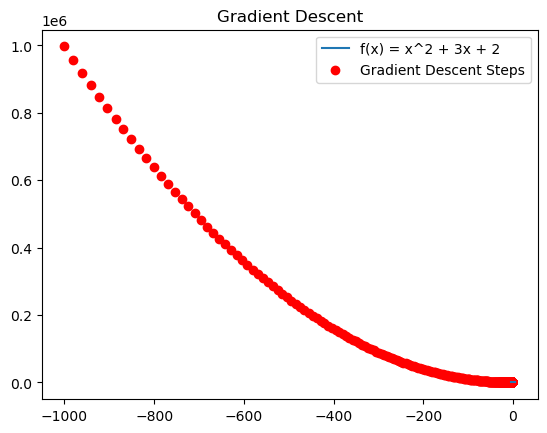

final x value: -1.500001680442906


In [ ]:
def gradient_descent_example():
    def gradient_descent(f, df, x0, lr=0.1, epochs=20):
        x_vals = [x0]
        for _ in range(epochs):
            # next x value = current x value - learning rate * derivative of f at current x value
            x_next = x_vals[-1] - lr * df(x_vals[-1])

            if abs(x_next - x_vals[-1]) < 0.01:
                break   
            x_vals.append(x_next)
        return x_vals

    # Define the function and its derivative
    f = lambda x: x**2 + 3*x + 2
    df = lambda x: 2*x + 3

    # Perform gradient descent
    x_vals = gradient_descent(f, df, x0=-1000, lr=0.01,epochs=1000)
    y_vals = [f(x) for x in x_vals]

    # Plot the optimization process
    x_space = np.linspace(-5, 5, 500)
    y_space = [f(x) for x in x_space]
    plt.plot(x_space, y_space, label="f(x) = x^2 + 3x + 2")
    plt.scatter(x_vals, y_vals, color='red', label="Gradient Descent Steps")
    plt.legend()
    plt.title("Gradient Descent")
    plt.show()

    print("final x value:", x_vals[-1])

gradient_descent_example()